In [23]:
# LSTM

## Импорт библиотек

In [24]:
import warnings
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [25]:
warnings.filterwarnings('ignore')

In [26]:
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

## Загрузка данных

In [27]:
df = pd.read_csv('df_for_learning.csv', index_col=0)
df.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Атмосферное давление на уровне станции_lag_395,year,day,day_of_year_sin,day_of_year_cos,season,month_sin,month_cos,Средняя температура воздуха_mean_group,temp_delta_vs_all_stations
0,34059,1982-01-31,-9.2,0.0,69.125,5.125,0.0,0.750,0.000,0.0,...,983.0500,1982,31,0.508671,0.860961,1,0.500000,0.866025,-8.820930,0.110631
1,34059,1982-02-01,-11.8,0.0,68.125,3.375,0.0,1.750,0.125,0.0,...,980.3750,1982,1,0.523416,0.852078,1,0.866025,0.500000,-8.623256,0.519601
2,34059,1982-02-02,-15.2,0.0,67.625,1.000,0.0,0.375,0.000,0.0,...,984.6000,1982,2,0.538005,0.842942,1,0.866025,0.500000,-9.165116,0.276744
3,34059,1982-02-03,-16.3,0.0,53.500,0.625,0.0,0.250,0.000,0.0,...,981.3750,1982,3,0.552435,0.833556,1,0.866025,0.500000,-9.504651,0.185382
4,34059,1982-02-04,-17.4,0.0,55.000,5.000,0.0,2.500,0.625,0.0,...,979.3875,1982,4,0.566702,0.823923,1,0.866025,0.500000,-8.655814,0.614618


In [28]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['Индекс ВМО', 'date']).reset_index(drop=True)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109053 entries, 0 to 109052
Data columns (total 57 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   Индекс ВМО                                      109053 non-null  int64         
 1   date                                            109053 non-null  datetime64[ns]
 2   Средняя температура воздуха                     109053 non-null  float64       
 3   Количество осадков                              109053 non-null  float64       
 4   Горизонтальная дальность видимости              109053 non-null  float64       
 5   Общее количество облачности                     109053 non-null  float64       
 6   Количество облачности нижнего яруса             109053 non-null  float64       
 7   Форма облаков верхнего яруса                    109053 non-null  float64       
 8   Форма облаков среднего яруса      

In [30]:
df.date.min(), df.date.max()

(Timestamp('1982-01-31 00:00:00'), Timestamp('2024-09-25 00:00:00'))

## Функции оценки точности

#### Простые метрики

In [31]:
def simple_metric(y_val, y_pred):
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_val - y_pred) / y_val)) * 100
    r2 = r2_score(y_val, y_pred)

    print("Простые метрики:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²: {r2:.4f}")
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

#### Ошибки по дням

In [32]:
def daily_metrics_lstm(val_df, y_pred, station_ids,
                       date_col='date',
                       station_col='Индекс ВМО',
                       target_col='Средняя температура воздуха'):

    val_df = val_df.sort_values([station_col, date_col]).copy()
    horizon = y_pred.shape[1]

    rows = []

    for i, station_id in enumerate(station_ids):
        station_df = val_df[val_df[station_col] == station_id].copy()
        station_df = station_df.sort_values(date_col)

        if len(station_df) < horizon:
            continue

        station_df = station_df.tail(horizon)
        station_df['prediction'] = y_pred[i]

        rows.append(station_df)

    df_plot = pd.concat(rows, axis=0)

    results = []

    for date, group in df_plot.groupby(date_col):
        y_true = group[target_col].values
        y_hat = group['prediction'].values

        mae = mean_absolute_error(y_true, y_hat)
        rmse = np.sqrt(mean_squared_error(y_true, y_hat))
        r2 = r2_score(y_true, y_hat)

        results.append({
            'date': date,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

    return pd.DataFrame(results).sort_values('date')

#### Столбчатые диаграммы ошибок по индексам


In [33]:
def metrics_per_index_lstm(val_df, y_pred, station_ids,
                          index_col='Индекс ВМО',
                          date_col='date',
                          target_col='Средняя температура воздуха'):

    val_df = val_df.sort_values([index_col, date_col]).copy()
    horizon = y_pred.shape[1]

    rows = []
    for i, station_id in enumerate(station_ids):
        station_df = val_df[val_df[index_col] == station_id].copy()
        station_df = station_df.sort_values(date_col)

        if len(station_df) < horizon:
            continue

        station_df = station_df.tail(horizon)
        station_df['prediction'] = y_pred[i]

        rows.append(station_df)

    df_plot = pd.concat(rows, axis=0)

    metrics_list = []

    for idx, group in df_plot.groupby(index_col):
        y_true = group[target_col].values
        y_hat = group['prediction'].values

        mae = mean_absolute_error(y_true, y_hat)
        rmse = np.sqrt(mean_squared_error(y_true, y_hat))
        r2 = r2_score(y_true, y_hat) if len(y_true) > 1 else np.nan

        metrics_list.append({
            index_col: idx,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

    metrics_df = pd.DataFrame(metrics_list).sort_values(index_col)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    axes[0].bar(metrics_df[index_col].astype(str), metrics_df['MAE'])
    axes[0].set_title('MAE по индексам')
    axes[0].set_ylabel('MAE')

    axes[1].bar(metrics_df[index_col].astype(str), metrics_df['RMSE'])
    axes[1].set_title('RMSE по индексам')
    axes[1].set_ylabel('RMSE')

    axes[2].bar(metrics_df[index_col].astype(str), metrics_df['R2'])
    axes[2].set_title('R² по индексам')
    axes[2].set_ylabel('R²')

    for ax in axes:
        ax.set_xlabel('Индекс ВМО')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return metrics_df

#### Линейный график MAE

In [34]:
def cumulative_mae_lstm(val_df, y_pred, station_ids,
                       date_col='date',
                       station_col='Индекс ВМО',
                       target_col='Средняя температура воздуха'):

    val_df = val_df.sort_values([station_col, date_col]).copy()
    horizon = y_pred.shape[1]

    rows = []

    for i, station_id in enumerate(station_ids):
        station_df = val_df[val_df[station_col] == station_id].copy()
        station_df = station_df.sort_values(date_col)

        if len(station_df) < horizon:
            continue

        station_df = station_df.tail(horizon)
        station_df['prediction'] = y_pred[i]

        rows.append(station_df)

    df_plot = pd.concat(rows, axis=0)

    df_plot = df_plot.sort_values(date_col)

    cum_errors = []
    all_true = []
    all_pred = []

    for date, group in df_plot.groupby(date_col):
        all_true.extend(group[target_col].values)
        all_pred.extend(group['prediction'].values)

        mae = mean_absolute_error(all_true, all_pred)

        cum_errors.append({
            'date': date,
            'Cumulative_MAE': mae
        })

    cum_df = pd.DataFrame(cum_errors)

    plt.figure(figsize=(12, 5))
    plt.plot(cum_df['date'], cum_df['Cumulative_MAE'], marker='o')
    plt.xlabel('Дата')
    plt.ylabel('MAE')
    plt.title('MAE по дням (LSTM)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return cum_df

#### Накопление ошибки Mae


In [35]:
def cumulative_error_lstm(val_df, y_pred, station_ids,
                         date_col='date',
                         station_col='Индекс ВМО',
                         target_col='Средняя температура воздуха'):

    val_df = val_df.sort_values([station_col, date_col]).copy()
    horizon = y_pred.shape[1]

    rows = []

    for i, station_id in enumerate(station_ids):
        station_df = val_df[val_df[station_col] == station_id].copy()
        station_df = station_df.sort_values(date_col)

        if len(station_df) < horizon:
            continue

        station_df = station_df.tail(horizon)
        station_df['prediction'] = y_pred[i]

        rows.append(station_df)

    df_plot = pd.concat(rows, axis=0)

    df_plot = df_plot.sort_values(date_col)

    cum_errors = []
    total_error = 0

    for date, group in df_plot.groupby(date_col):
        daily_error = np.abs(group[target_col] - group['prediction']).sum()
        total_error += daily_error

        cum_errors.append({
            'date': date,
            'Cumulative_Error': total_error
        })

    cum_df = pd.DataFrame(cum_errors)

    plt.figure(figsize=(12, 5))
    plt.plot(cum_df['date'], cum_df['Cumulative_Error'], marker='o')
    plt.xlabel('Дата')
    plt.ylabel('Cumulative Absolute Error')
    plt.title('Накопление абсолютной ошибки (LSTM)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return cum_df

#### Сравнения истинной средней и предсказанной средней


In [36]:
def plot_true_vs_pred(val_df, y_pred, station_ids,
                     date_col='date',
                     station_col='Индекс ВМО',
                     target_col='Средняя температура воздуха'):

    val_df = val_df.sort_values([station_col, date_col]).copy()

    preds_list = []

    horizon = y_pred.shape[1]

    for i, station_id in enumerate(station_ids):
        station_df = val_df[val_df[station_col] == station_id].copy()
        station_df = station_df.sort_values(date_col)

        if len(station_df) < horizon:
            continue

        # берём последние 30 дней
        station_df = station_df.tail(horizon)

        station_df['prediction'] = y_pred[i]
        preds_list.append(station_df)

    if len(preds_list) == 0:
        raise ValueError("Нет данных для построения графика")

    df_plot = pd.concat(preds_list, axis=0)

    # агрегируем по дате
    daily_true = df_plot.groupby(date_col)[target_col].mean()
    daily_pred = df_plot.groupby(date_col)['prediction'].mean()


    plt.figure(figsize=(12, 6))

    plt.plot(daily_true.index, daily_true.values, label='True', marker='o')
    plt.plot(daily_pred.index, daily_pred.values, label='Pred', linestyle='--', marker='x')

    plt.legend()
    plt.title('True vs Pred (last 30 days)')
    plt.xticks(rotation=45)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

#### Сравнение истинной и предсказанной по индексам

In [37]:
def plot_true_vs_pred_by_index(val_df, y_pred, station_ids,
                              date_col='date',
                              index_col='Индекс ВМО',
                              target_col='Средняя температура воздуха'):

    val_df = val_df.sort_values([index_col, date_col]).copy()

    horizon = y_pred.shape[1]

    n_indices = len(station_ids)

    # сетка графиков
    n_cols = 2
    n_rows = (n_indices + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3), sharex=False, sharey=False)
    axes = axes.flatten()

    for i, station_id in enumerate(station_ids):
        ax = axes[i]

        station_df = val_df[val_df[index_col] == station_id].copy()
        station_df = station_df.sort_values(date_col)

        if len(station_df) < horizon:
            ax.set_title(f'{station_id} (skip)')
            ax.axis('off')
            continue

        # берём последние 30 дней
        station_df = station_df.tail(horizon)

        y_true = station_df[target_col].values
        y_hat = y_pred[i]

        ax.plot(station_df[date_col], y_true, label='True', marker='o')
        ax.plot(station_df[date_col], y_hat, label='Pred', linestyle='--', marker='x')

        ax.set_title(f'Индекс ВМО: {station_id}')
        ax.grid(True)

        if i % n_cols == 0:
            ax.set_ylabel('Температура')

        ax.tick_params(axis='x', rotation=45)
        ax.legend(fontsize=8)

    # скрываем пустые
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

## Построение модели LSTM

### Задание параметров

In [38]:
TARGET_COL = 'Средняя температура воздуха'
WINDOW = 30
HORIZON = 30

### Разделение данных

In [39]:
val_start = df['date'].max() - pd.Timedelta(days=HORIZON)

train_df = df[df['date'] < val_start].copy()
val_df = df[df['date'] >= val_start].copy()

print("Train:", train_df.shape)
print("Val:", val_df.shape)

Train: (108836, 57)
Val: (217, 57)


### Создание последовательностей для train

In [40]:
def create_sequences_multi(df, target_col, window=30, horizon=30):
    X, y = [], []

    for station_id, group in df.groupby('Индекс ВМО'):
        group = group.sort_values('date')

        features = group.drop(columns=['date']).values
        target = group[target_col].values

        for i in range(len(group) - window - horizon + 1):
            X.append(features[i:i + window])
            y.append(target[i + window:i + window + horizon])

    return np.array(X), np.array(y)

In [41]:
X_train, y_train = create_sequences_multi(train_df, TARGET_COL, WINDOW, HORIZON)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (108423, 30, 56)
y_train: (108423, 30)


### Создание окна для последнего месяца

In [42]:
def create_last_window(df, window=30):
    X_last = []
    station_ids = []

    for station_id, group in df.groupby('Индекс ВМО'):
        group = group.sort_values('date')

        if len(group) < window:
            print('Что-то не так!!!')
            continue

        last_window = group.drop(columns=['date']).values[-window:]
        X_last.append(last_window)
        station_ids.append(station_id)

    return np.array(X_last), station_ids

In [43]:
X_val, station_ids = create_last_window(train_df, WINDOW)

print("X_val:", X_val.shape)

X_val: (7, 30, 56)


### Нормализация

In [44]:
n_samples, n_steps, n_features = X_train.shape

scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_val_2d = X_val.reshape(-1, n_features)

X_train_scaled = scaler.fit_transform(X_train_2d)
X_val_scaled = scaler.transform(X_val_2d)

X_train = X_train_scaled.reshape(n_samples, n_steps, n_features)
X_val = X_val_scaled.reshape(X_val.shape[0], n_steps, n_features)

In [45]:
# y_scaler = StandardScaler()
#
# y_train_2d = y_train.reshape(-1, 1)
# y_train_scaled = y_scaler.fit_transform(y_train_2d).reshape(y_train.shape)

### Построение и обучение модели

In [46]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [47]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, n_features)),
    LSTM(64, return_sequences=True),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(HORIZON)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


model.summary()

# TRAIN
model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=64,
    verbose=1
)

# model.fit(
#     X_train, y_train,
#     validation_split=0.1,
#     epochs=50,
#     batch_size=64,
#     callbacks=[early_stop],
#     verbose=1
# )

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        30,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,094 (1.22 MB)

 Trainable params: 320,094 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - loss: 20.6015 - mae: 3.5324
Epoch 2/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - loss: 11.4273 - mae: 2.6478
Epoch 3/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 8.3630 - mae: 2.2429
Epoch 4/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - loss: 6.8327 - mae: 2.0187
Epoch 5/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - loss: 5.8547 - mae: 1.8615
Epoch 6/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - loss: 5.1817 - mae: 1.7466
Epoch 7/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 4.7159 - mae: 1.6641
Epoch 8/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - loss: 4.3451 - mae: 1.5968
Epoch 9/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 74s 42ms/step - loss: 4.0250 - mae: 1.5364
Epoch 10/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - loss: 3.7623 - mae: 1.4844
Epoch 11/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - loss: 3.5431 - mae: 1.4393
Epoch 12/12
1695/1695 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - lo

### Предсказание

In [48]:
y_pred = model.predict(X_val)

print("y_pred shape:", y_pred.shape)  # (n_stations, 30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
y_pred shape: (7, 30)


In [49]:
def get_true_last(df, horizon=30):
    y_true = []

    for station_id, group in df.groupby('Индекс ВМО'):
        group = group.sort_values('date')

        if len(group) < horizon:
            continue

        y_true.append(group[TARGET_COL].values[-horizon:])

    return np.array(y_true)


y_val_true = get_true_last(df, HORIZON)

print("y_val_true shape:", y_val_true.shape)

mae = np.mean(np.abs(y_val_true - y_pred))
print("MAE (val, last 30 days):", mae)

y_val_true shape: (7, 30)
MAE (val, last 30 days): 2.3602105603899273


## Результат

In [50]:
simple_metric(y_val_true, y_pred)

Простые метрики:
MAE: 2.3602
MSE: 8.7305
RMSE: 2.9547
MAPE: 12.82%
R²: -12.1426


{'MAE': 2.3602105603899277,
 'MSE': 8.73045482022608,
 'RMSE': np.float64(2.9547343061984574),
 'MAPE': np.float64(12.821361241778492),
 'R2': -12.142640887712446}

In [51]:
# Простые метрики:
# MAE: 2.3602
# MSE: 8.7305
# RMSE: 2.9547
# MAPE: 12.82%
# R²: -12.1426
# {'MAE': 2.3602105603899277,
#  'MSE': 8.73045482022608,
#  'RMSE': np.float64(2.9547343061984574),
#  'MAPE': np.float64(12.821361241778492),
#  'R2': -12.142640887712446}

In [52]:
# Простые метрики:
# MAE: 2.2967
# MSE: 7.6634
# RMSE: 2.7683
# MAPE: 12.46%
# R²: -11.4362
# {'MAE': 2.296705726441883,
#  'MSE': 7.663381013601805,
#  'RMSE': np.float64(2.7682812381695987),
#  'MAPE': np.float64(12.458791539905576),
#  'R2': -11.436202572226758}

In [53]:
# Простые метрики:
# MAE: 2.4334
# MSE: 8.3286
# RMSE: 2.8859
# MAPE: 13.22%
# R²: -13.9980
# {'MAE': 2.4334070441836397,
#  'MSE': 8.328596360402546,
#  'RMSE': np.float64(2.8859307615399485),
#  'MAPE': np.float64(13.219313185678958),
#  'R2': -13.997996462961863}

In [54]:
# Простые метрики:
# MAE: 2.5671
# MSE: 10.1874
# RMSE: 3.1918
# MAPE: 14.49%
# R²: -22.9511
# {'MAE': 2.5670682098751976,
#  'MSE': 10.187409655295433,
#  'RMSE': np.float64(3.191772180982758),
#  'MAPE': np.float64(14.494043242578591),
#  'R2': -22.951125595980447}

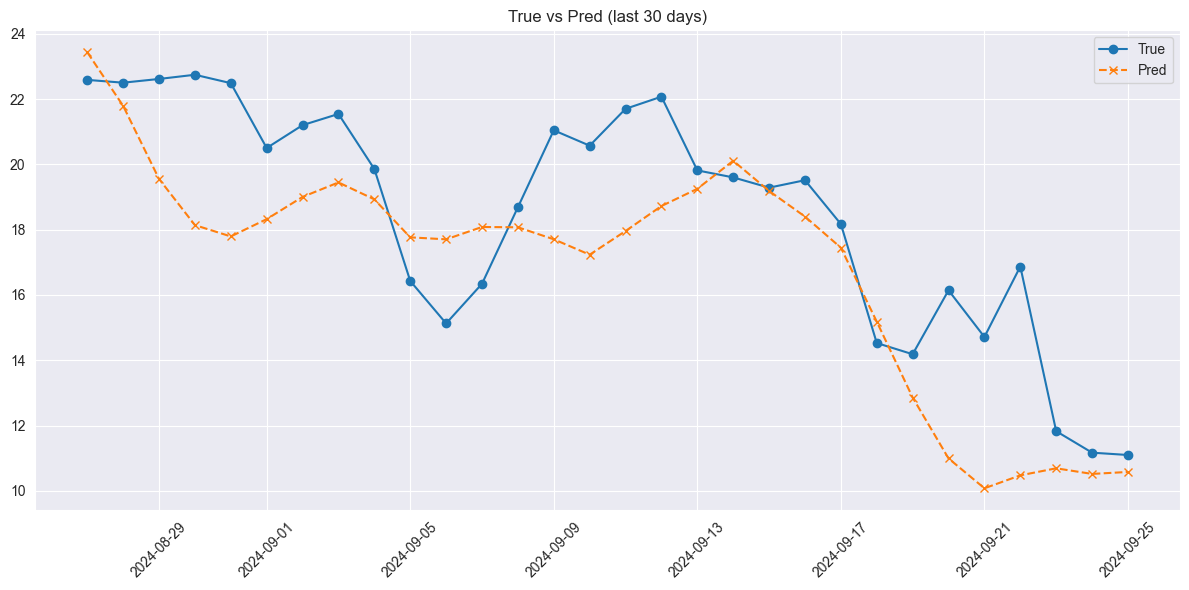

In [55]:
plot_true_vs_pred(val_df, y_pred, station_ids)

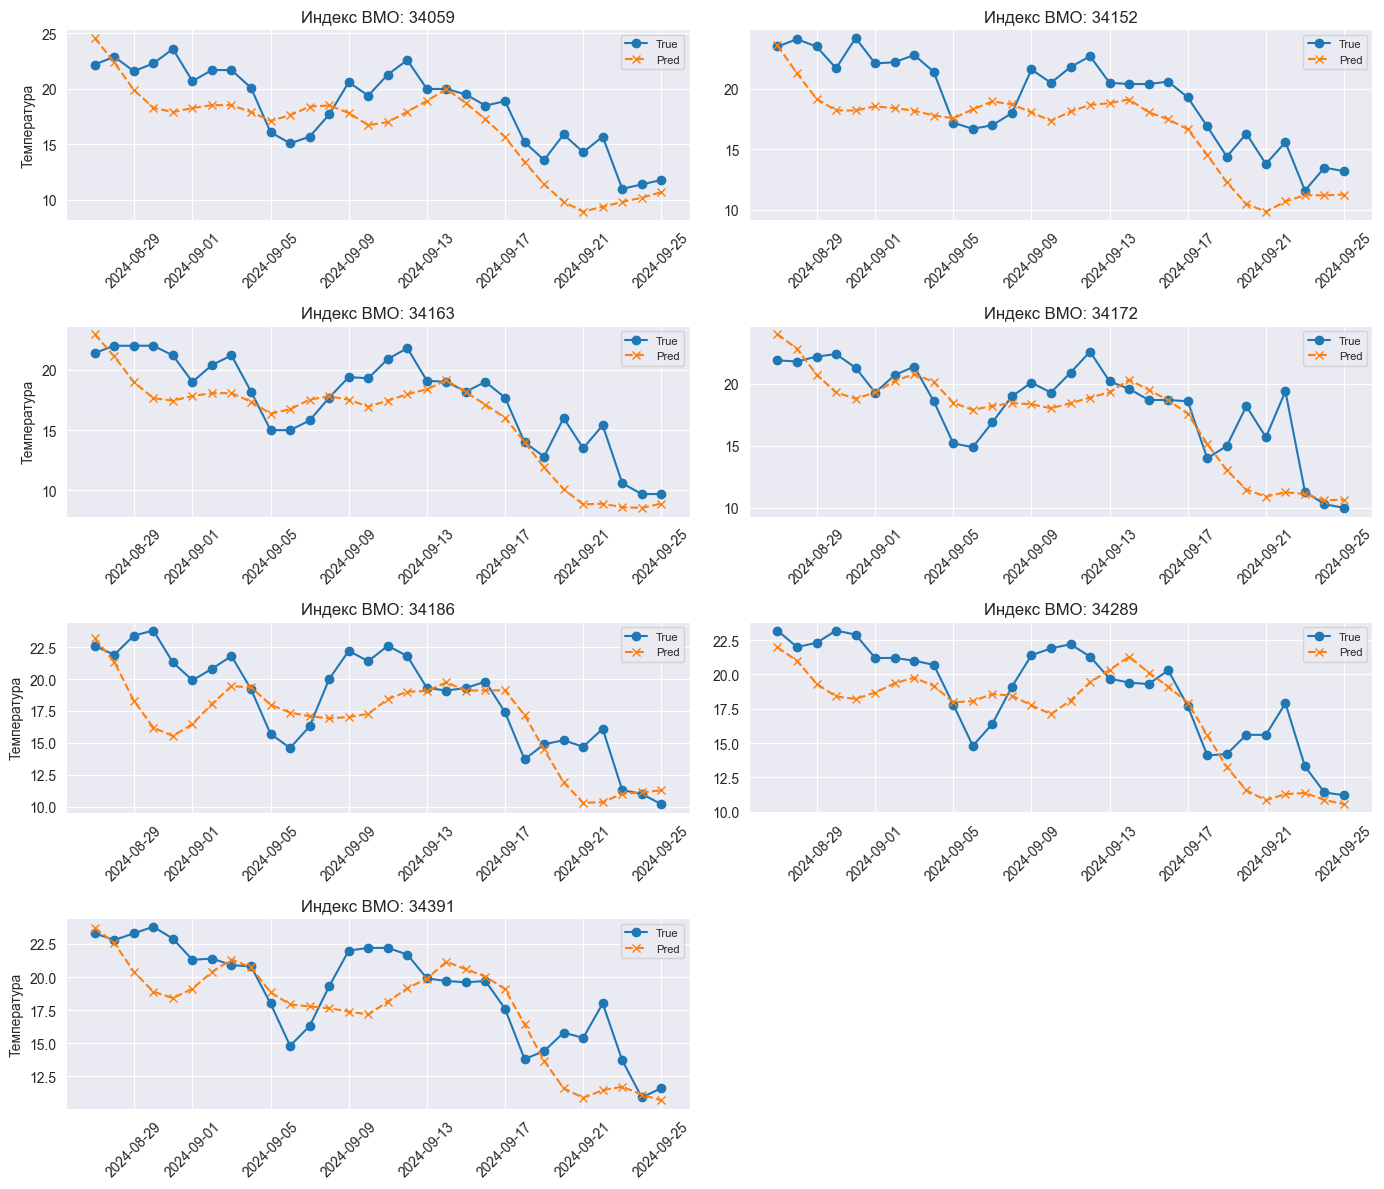

In [56]:
plot_true_vs_pred_by_index(val_df, y_pred, station_ids)

In [57]:
df_metrics = daily_metrics_lstm(val_df, y_pred, station_ids)

df_metrics

,date,MAE,RMSE,R2
0,2024-08-27,1.197633,1.443131,-2.889052
1,2024-08-28,1.005426,1.278276,-1.749500
2,2024-08-29,3.061054,3.289925,-20.350915
3,2024-08-30,4.603950,4.803243,-35.727945
4,2024-08-31,4.693419,4.836731,-17.218443
5,2024-09-01,2.179733,2.467369,-4.477556
6,2024-09-02,2.197240,2.451974,-16.985141
7,2024-09-03,2.218276,2.634980,-18.308328
8,2024-09-04,1.419782,1.822538,-1.643074
9,2024-09-05,1.335696,1.680174,-1.163376


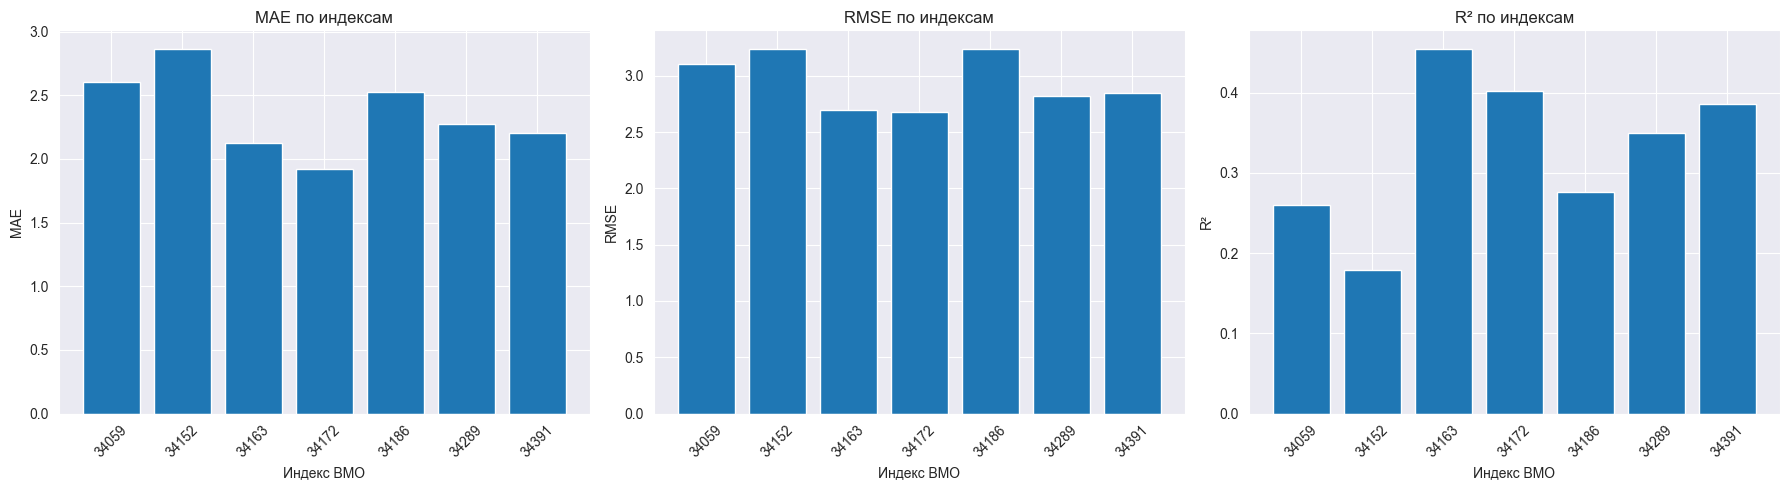

   Индекс ВМО       MAE      RMSE        R2
0       34059  2.605640  3.103947  0.259840
1       34152  2.867340  3.233024  0.179160
2       34163  2.126325  2.697546  0.455016
3       34172  1.917842  2.681344  0.402093
4       34186  2.526419  3.241031  0.275623
5       34289  2.275796  2.821748  0.349336
6       34391  2.202111  2.844883  0.385392


In [58]:
metrics_df = metrics_per_index_lstm(val_df, y_pred, station_ids)

print(metrics_df)

34172 - индекс станции Саратова, скорее всего город сильно отличается от всех остальных городов, и поэтому хуже всего результаты

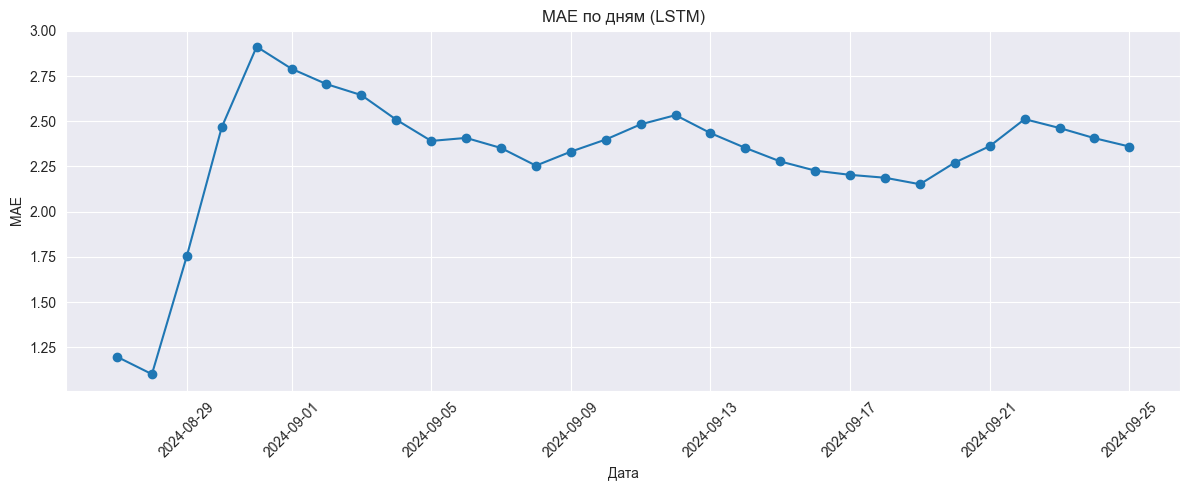

        date  Cumulative_MAE
0 2024-08-27        1.197633
1 2024-08-28        1.101529
2 2024-08-29        1.754704
3 2024-08-30        2.467015
4 2024-08-31        2.912296


In [59]:
cum_df = cumulative_mae_lstm(val_df, y_pred, station_ids)

print(cum_df.head())

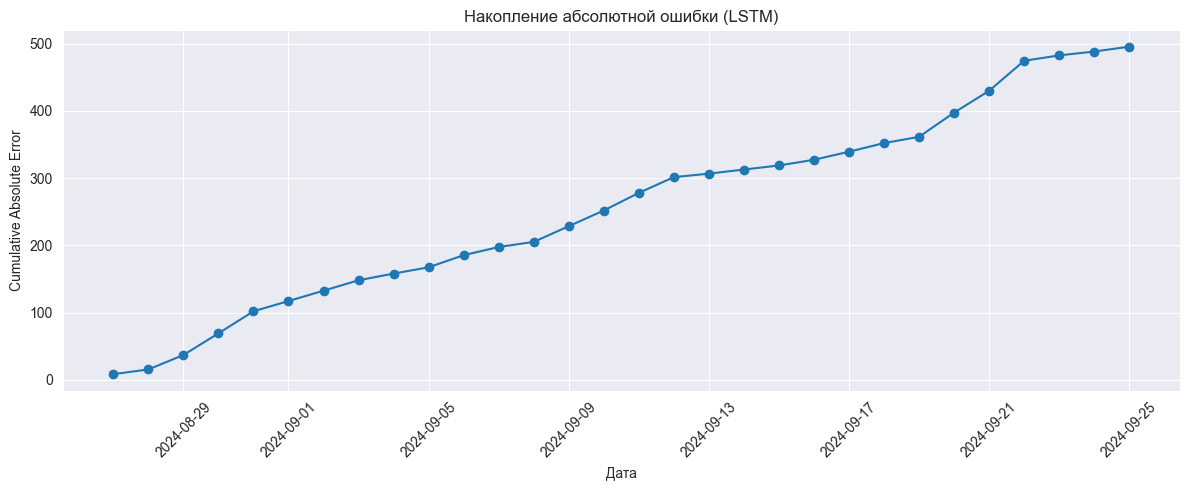

        date  Cumulative_Error
0 2024-08-27          8.383429
1 2024-08-28         15.421409
2 2024-08-29         36.848785
3 2024-08-30         69.076432
4 2024-08-31        101.930367


In [60]:
cum_err_df = cumulative_error_lstm(val_df, y_pred, station_ids)

print(cum_err_df.head())

## Важность признаков

In [61]:
def permutation_importance_lstm(model, X_val, y_true, n_repeats=3):
    """
    model     — обученная модель
    X_val     — (n_samples, window, n_features)
    y_true    — (n_samples, horizon)
    n_repeats — сколько раз перемешивать (для стабильности)
    """

    # базовый прогноз
    y_pred = model.predict(X_val, verbose=0)
    baseline_mae = np.mean(np.abs(y_true - y_pred))

    n_features = X_val.shape[2]
    importances = []

    for feature_idx in range(n_features):
        scores = []

        for _ in range(n_repeats):
            X_perm = X_val.copy()

            # перемешиваем ОДИН признак
            flat = X_perm[:, :, feature_idx].reshape(-1)
            np.random.shuffle(flat)
            X_perm[:, :, feature_idx] = flat.reshape(X_perm[:, :, feature_idx].shape)

            y_pred_perm = model.predict(X_perm, verbose=0)
            mae_perm = np.mean(np.abs(y_true - y_pred_perm))

            scores.append(mae_perm - baseline_mae)

        importances.append(np.mean(scores))

    return np.array(importances), baseline_mae

In [62]:
importances, base_mae = permutation_importance_lstm(
    model, X_val, y_val_true, n_repeats=3
)

print("Baseline MAE:", base_mae)

Baseline MAE: 2.3602105603899273


In [63]:
feature_names = train_df.drop(columns=['date']).columns.tolist()

importance_df = sorted(
    zip(feature_names, importances),
    key=lambda x: x[1],
    reverse=True
)

for name, score in importance_df:
    print(f"{name}: {score:.6f}")

Атмосферное давление на уровне моря_lag_335: 0.189284
Атмосферное давление на уровне станции_lag_335: 0.136015
Характеристика барической тенденции: 0.093612
Атмосферное давление на уровне станции_lag_395: 0.090968
Индекс ВМО: 0.060761
Максимальная скорость ветра: 0.054635
Сумма осадков: 0.053830
Общее количество облачности: 0.049737
Относительная влажность воздуха_lag_395: 0.047101
Температура поверхности почвы_lag_335: 0.039628
Погода между сроками: 0.038971
Средняя температура воздуха_lag_365: 0.037103
Средняя температура воздуха_lag_335: 0.036908
month_cos: 0.033825
month_sin: 0.029705
Парциальное давление водяного пара: 0.023370
Средняя температура воздуха_mean_group: 0.022104
Дефицит насыщения водяного пара_lag_365: 0.020627
day_of_year_sin: 0.011769
Средняя температура воздуха: 0.009786
Температура поверхности почвы_lag_395: 0.008288
Атмосферное давление на уровне моря_lag_365: 0.006124
Погода в срок наблюдения: 0.005641
Слоистые и слоисто_кучевые облака: 0.004657
day_of_year_cos

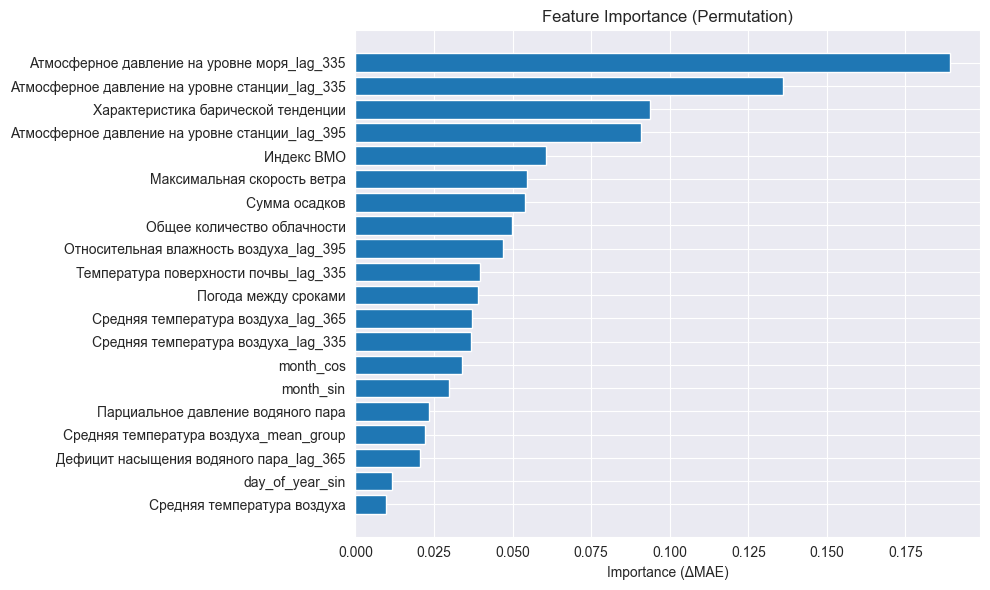

In [64]:
# берём топ-20
top_k = 20
top_features = importance_df[:top_k]

names = [x[0] for x in top_features]
values = [x[1] for x in top_features]

plt.figure(figsize=(10, 6))
plt.barh(names[::-1], values[::-1])  # переворот, чтобы самый важный был сверху
plt.xlabel("Importance (ΔMAE)")
plt.title("Feature Importance (Permutation)")

plt.tight_layout()
plt.show()